   statefips  countyfips  avghouseholdsize                           geography
0          2          13              2.43      Aleutians East Borough, Alaska
1          2          16              3.59  Aleutians West Census Area, Alaska
2          2          20              2.77      Anchorage Municipality, Alaska
3          2          50              3.86          Bethel Census Area, Alaska
4          2          60              2.50         Bristol Bay Borough, Alaska
(3220, 4)
Index(['statefips', 'countyfips', 'avghouseholdsize', 'geography'], dtype='object')
statefips             int64
countyfips            int64
avghouseholdsize    float64
geography            object
dtype: object
         statefips   countyfips  avghouseholdsize
count  3220.000000  3220.000000       3220.000000
mean     31.290683   102.922050          2.540755
std      16.277207   106.693846          0.267654
min       1.000000     1.000000          1.370000
25%      19.000000    35.000000          2.380000
50%   

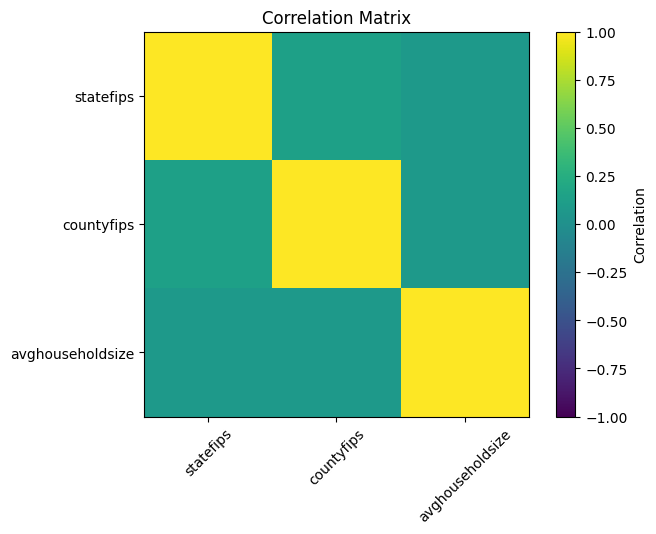

X:
   countyfips
0          13
1          16
2          20
3          50
4          60
y:
0    2.43
1    3.59
2    2.77
3    3.86
4    2.50
Name: avghouseholdsize, dtype: float64
Training: (2576, 1)
Testing: (644, 1)
Intercept: 2.51828053429361
Coefficient: 0.00020246629637017043
Equation: y = 2.5183 + (0.0002)x
Predictions:
[2.54034936 2.56545518 2.55087761 2.54034936 2.54399375 2.54075429
 2.52374712 2.52212739 2.5196978  2.5395395 ]
   Actual  Predicted
0    2.39   2.540349
1    2.78   2.565455
2    2.25   2.550878
3    2.49   2.540349
4    2.43   2.543994
5    2.52   2.540754
6    2.36   2.523747
7    2.76   2.522127
8    2.68   2.519698
9    2.49   2.539539
Residuals:
[-0.15034936  0.21454482 -0.30087761 -0.05034936 -0.11399375 -0.02075429
 -0.16374712  0.23787261  0.1603022  -0.0495395 ]
MSE: 0.07347497404847306
MAE: 0.18939421761516897
RMSE: 0.27106267549862534
R²: -0.0010554341500621511


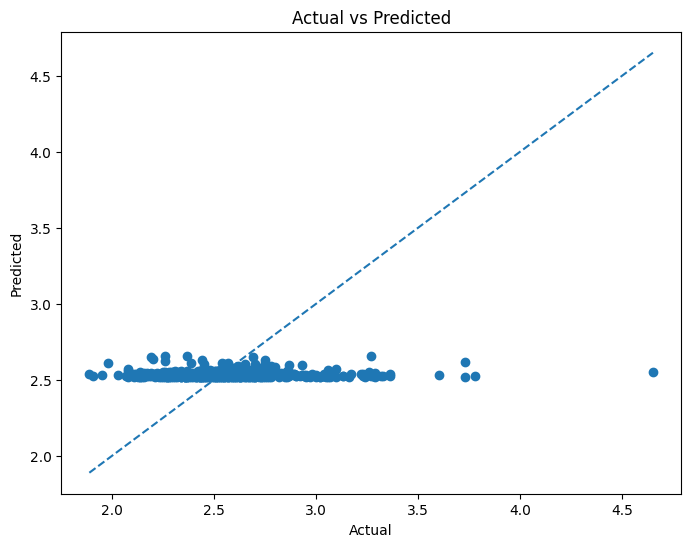

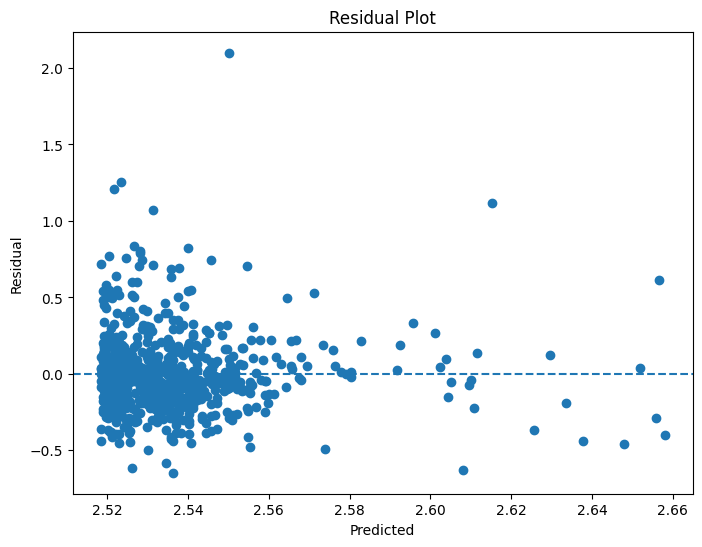

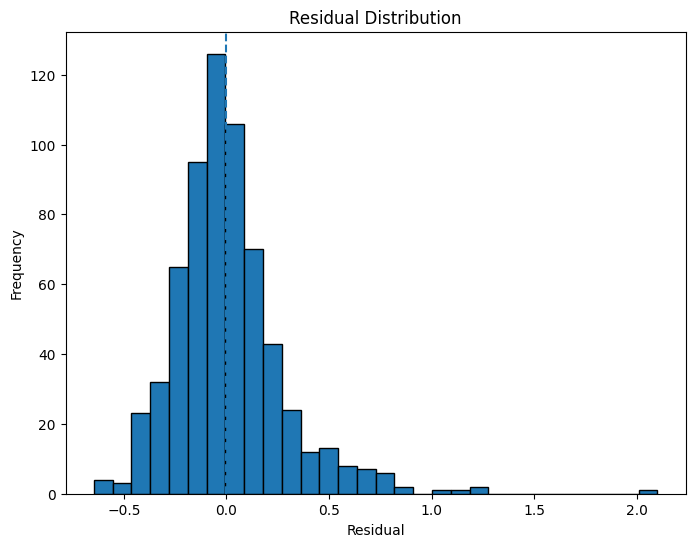

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data
df = pd.read_csv("/content/avg-household-size.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Data Cleaning
df = df.drop_duplicates()
df = df.dropna()

print("Shape after cleaning:", df.shape)

# Correlation
correlation = df.corr(numeric_only=True)
print(correlation)

plt.figure(figsize=(7, 5))
plt.imshow(correlation, cmap="viridis", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.show()

# X and y
X = df[["countyfips"]]
y = df["avghouseholdsize"]

print("X:")
print(X.head())

print("y:")
print(y.head())

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

# Linear Regression
model = LinearRegression()

# Fit
model.fit(X_train, y_train)

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

print(
    f"Equation: y = {model.intercept_:.4f} + "
    f"({model.coef_[0]:.4f})x"
)

# Predict
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

# Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(10))

# Residual Error
residuals = y_test.values - y_pred

print("Residuals:")
print(residuals[:10])

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# Residual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

# Residual Distribution
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor="black")
plt.axvline(x=0, linestyle="--")

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()